# Cross-Section Node Analysis: Model Comparison

This notebook selects representative nodes that lie **within the 2D cross-section corridor** defined in `cross_section_analysis.ipynb`, then produces:
1. A **2D cross-section plot** (final time-step mass concentration) with the selected nodes overlaid.
2. **Time-series comparison plots** (Mass Concentration + Hydraulic Head) for each selected node.

The cross-section is the vertical transect between **P1** and **P2** as defined in `cross_section_analysis.ipynb`.

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.tri as mtri
from scipy.spatial import KDTree

In [2]:
# ── Directory paths (mirror plot_results.ipynb) ──────────────────────────────
gino_vl_dir = '/scratch/yl75/ak4177/results/groundwater/GINO_predictions/var_loss/resolution_1.0/gino_predictions_20260721_072032'
gino_dir    = '/scratch/yl75/ak4177/results/groundwater/GINO_predictions/standard/resolution_1.0/gino_predictions_20260721_072032'
fno_dir     = '/scratch/yl75/ak4177/results/groundwater/FNO_predictions/forcing/resolution_1.0/fno_predictions_20260721_130903'

# Cross-section results directory (mirror cross_section_analysis.ipynb)
cs_results_dir = '/scratch/yl75/ak4177/results/groundwater/GINO_predictions/standard/resolution_1.0/gino_predictions_20260722_084337'

# FEFLOW ASCII mesh
feflow_mesh_path = '/scratch/yl75/ak4177/data/feflow_data/ascii_mesh.fem'

# Dataset split to use for node selection and time-series plots
dataset = 'val'

In [3]:
# ── Load predictions and observations ────────────────────────────────────────
def read_results(results_dir, dataset='val'):
    preds = np.load(os.path.join(results_dir, f'{dataset}_predictions.npy'))
    obs   = np.load(os.path.join(results_dir, f'{dataset}_targets.npy'))
    preds = preds.squeeze().transpose(1, 0, 2)   # → (N_nodes, T, N_vars)
    obs   = obs.squeeze().transpose(1, 0, 2)
    return preds, obs

gino_vl_preds, gino_vl_obs = read_results(gino_vl_dir, dataset)
gino_preds,    gino_obs    = read_results(gino_dir,     dataset)
fno_preds,     fno_obs     = read_results(fno_dir,      dataset)

print(f"Loaded  gino_vl: preds {gino_vl_preds.shape},  obs {gino_vl_obs.shape}")
print(f"Loaded  gino:    preds {gino_preds.shape},  obs {gino_obs.shape}")
print(f"Loaded  fno:     preds {fno_preds.shape},  obs {fno_obs.shape}")

Loaded  gino_vl: preds (61360, 568, 2),  obs (61360, 568, 2)
Loaded  gino:    preds (61360, 568, 2),  obs (61360, 568, 2)
Loaded  fno:     preds (61360, 568, 2),  obs (61360, 568, 2)


In [4]:
# ── Load and de-normalise node coordinates ────────────────────────────────────
coords = pickle.load(open(os.path.join(gino_vl_dir, f'{dataset}_coords.pkl'), 'rb'))[0]

coord_mean = np.array([357225.66528974305, 6457743.243307921, -9.277822477621577])
coord_std  = np.array([569.1699998979727,  566.3579737855055, 15.2656561762675])
unnorm_coords = coords * coord_std + coord_mean

print(f"Coordinates shape: {unnorm_coords.shape}")
print(f"X range: {unnorm_coords[:,0].min():.1f} – {unnorm_coords[:,0].max():.1f}")
print(f"Y range: {unnorm_coords[:,1].min():.1f} – {unnorm_coords[:,1].max():.1f}")
print(f"Z range: {unnorm_coords[:,2].min():.1f} – {unnorm_coords[:,2].max():.1f}")

Coordinates shape: (61360, 3)
X range: 355702.4 – 358346.0
Y range: 6456013.4 – 6459171.0
Z range: -40.0 – 33.9


## Transect Geometry

Same transect as in `cross_section_analysis.ipynb`.

In [5]:
# ── Transect P1 → P2 (from cross_section_analysis.ipynb) ────────────────────
p1 = np.array([356835.28, 6459067.43])
p2 = np.array([357877.28, 6457548.86])

dx_L   = p2[0] - p1[0]
dy_L   = p2[1] - p1[1]
length = np.hypot(dx_L, dy_L)

# Unit vectors
tx = dx_L / length   # along-transect
ty = dy_L / length

print(f"Transect length: {length:.1f} m")
print(f"P1 = {p1},  P2 = {p2}")

Transect length: 1841.7 m
P1 = [ 356835.28 6459067.43],  P2 = [ 357877.28 6457548.86]


In [6]:
# ── Project all nodes onto the transect axis ─────────────────────────────────
rel_x = unnorm_coords[:, 0] - p1[0]
rel_y = unnorm_coords[:, 1] - p1[1]

s_nodes = rel_x * tx + rel_y * ty            # distance along transect (m)
n_nodes = np.abs(-rel_x * ty + rel_y * tx)  # perpendicular distance (m)
z_nodes = unnorm_coords[:, 2]               # elevation (m)

print(f"s range: {s_nodes.min():.1f} – {s_nodes.max():.1f} m")
print(f"n range: {n_nodes.min():.1f} – {n_nodes.max():.1f} m")

s range: 8.5 – 2354.9 m
n range: 0.2 – 1965.9 m


## Cross-section Corridor

We restrict node selection to the same bounding box used in `cross_section_analysis.ipynb`.

In [7]:
# ── Cross-section corridor filter ────────────────────────────────────────────
transect_width_tol = 150   # metres either side of the transect

s_min, s_max =  200.0, 1850.0   # metres along transect
n_max        = transect_width_tol

in_corridor = (
    (s_nodes >= s_min) & (s_nodes <= s_max) &
    (n_nodes <= n_max)
)

corridor_indices = np.where(in_corridor)[0]
print(f"Nodes inside cross-section corridor: {len(corridor_indices)}")
print(f"Z range of corridor nodes: {z_nodes[in_corridor].min():.1f} – {z_nodes[in_corridor].max():.1f} m")

Nodes inside cross-section corridor: 9568
Z range of corridor nodes: -40.0 – 26.8 m


## Select Representative Nodes Within the Cross-Section

We pick one representative node per hydrological zone (transition, saturated, unsaturated) — all constrained to nodes that lie within the cross-section corridor.

In [8]:
# ── Compute per-node NMAE (for each model) ───────────────────────────────────
def compute_nmae(preds, obs):
    """Return NMAE array of shape (N_vars, N_nodes)."""
    nmae = []
    for idx in range(obs.shape[-1]):
        denom = obs[..., idx].std(axis=(0, 1)) + 1e-12
        nmae.append(np.mean(np.abs(preds[..., idx] - obs[..., idx]), axis=1) / denom)
    return np.array(nmae)

gino_vl_nmae = compute_nmae(gino_vl_preds, gino_vl_obs)   # shape (2, N_nodes)
fno_nmae     = compute_nmae(fno_preds,     fno_obs)

# ── Hydrological zone masks WITHIN the corridor ───────────────────────────────
transition_mask  = in_corridor & (z_nodes > -10) & (z_nodes < 2)
saturated_mask   = in_corridor & (z_nodes < -15)
unsaturated_mask = in_corridor & (z_nodes > 5)   # clearly above water table (mirrors plot_results.ipynb)

print(f"Transition  nodes in corridor: {transition_mask.sum()}")
print(f"Saturated   nodes in corridor: {saturated_mask.sum()}")
print(f"Unsaturated nodes in corridor: {unsaturated_mask.sum()}")

Transition  nodes in corridor: 2783
Saturated   nodes in corridor: 3315
Unsaturated nodes in corridor: 2042


In [9]:
# np.random.seed(95)
mass_conc_obs = fno_obs[..., 0]   # (N_nodes, T)  — raw units (mg/L)

# Global scale: divide by 1000 if values are in mg/L range (max > 100)
mc_global_scale = 1000.0 if mass_conc_obs.max() > 100 else 1.0

# ── Select Saturated Zone node ────────────────────────────────────────────────
# Target: stable, high concentration (~35 kg/m³).
# Strategy: top 25 % by mean → randomly select one weighted by stability
#           (inverse std) so stable nodes are preferred but variation is
#           preserved across runs.
sat_indices    = np.where(saturated_mask)[0]
mean_conc_sat  = mass_conc_obs[sat_indices, :].mean(axis=1)
std_conc_sat   = mass_conc_obs[sat_indices, :].std(axis=1)
high_mean_mask = mean_conc_sat >= np.percentile(mean_conc_sat, 75)
sat_candidates   = sat_indices[high_mean_mask]
sat_stds         = std_conc_sat[high_mean_mask]
# Weight by inverse-std so stable nodes are more likely (epsilon avoids /0)
inv_std_weights  = 1.0 / (sat_stds + 1e-12)
sat_weights      = inv_std_weights / inv_std_weights.sum()
saturated_idx    = np.random.choice(sat_candidates, p=sat_weights)

# ── Select Unsaturated Zone node ──────────────────────────────────────────────
# Target: near-zero, stable throughout ALL timesteps (never wetted).
# Strategy: filter to nodes whose MAX concentration over the full time series
#           is effectively zero (bottom 5 %), then randomly select one weighted
#           by proximity to the transect centre (closer = higher probability)
#           to avoid domain-edge artefacts while still allowing variation.
unsat_indices  = np.where(unsaturated_mask)[0]
max_conc_unsat = mass_conc_obs[unsat_indices, :].max(axis=1)

zero_thresh     = np.percentile(max_conc_unsat, 5)   # effectively zero
zero_candidates = unsat_indices[max_conc_unsat <= zero_thresh]
# Weight by inverse distance to transect centre (epsilon avoids /0)
s_centre        = (s_min + s_max) / 2.0
s_dist_centre   = np.abs(s_nodes[zero_candidates] - s_centre)
inv_dist_weights  = 1.0 / (s_dist_centre + 1e-6)
unsat_weights     = inv_dist_weights / inv_dist_weights.sum()
unsaturated_idx   = np.random.choice(zero_candidates, p=unsat_weights)

# ── Select Transition Zone node ───────────────────────────────────────────────
# Target: mean in the middle (not always high/low).
# Strategy: randomly select a node from the middle 50% of mean concentrations,
#           weighted so that nodes with a higher dynamic range have a higher 
#           chance of being selected.
transition_indices = np.where(transition_mask)[0]
mean_conc_tr       = mass_conc_obs[transition_indices, :].mean(axis=1)
dynamic_ranges     = np.ptp(mass_conc_obs[transition_indices, :], axis=1)

mid_lo   = np.percentile(mean_conc_tr, 25)
mid_hi   = np.percentile(mean_conc_tr, 75)
mid_mask = (mean_conc_tr >= mid_lo) & (mean_conc_tr <= mid_hi)

# Extract valid candidates and their corresponding dynamic ranges
valid_transition_candidates = transition_indices[mid_mask]
valid_dynamic_ranges        = dynamic_ranges[mid_mask]

# Calculate probabilities by normalizing the dynamic ranges so they sum to 1.0
# (Adding a tiny epsilon 1e-12 prevents division by zero if all ranges are flat)
weights = valid_dynamic_ranges / (valid_dynamic_ranges.sum() + 1e-12)

# Randomly select one index, weighted by the 'p' parameter
transition_idx = np.random.choice(valid_transition_candidates, p=weights)

selected = {
    'Transition Zone':  transition_idx,
    'Saturated Zone':   saturated_idx,
    'Unsaturated Zone': unsaturated_idx,
}

for name, idx in selected.items():
    mc = mass_conc_obs[idx, :]
    print(f"{name}: node={idx}  z={z_nodes[idx]:.1f}m  s={s_nodes[idx]:.0f}m  "
          f"mean={mc.mean()/mc_global_scale:.2f}  std={mc.std()/mc_global_scale:.2f}  "
          f"max={mc.max()/mc_global_scale:.2f}  min={mc.min()/mc_global_scale:.2f}  kg/m³")


Transition Zone: node=7923  z=-0.5m  s=764m  mean=10.86  std=4.82  max=26.37  min=3.11  kg/m³
Saturated Zone: node=55349  z=-35.0m  s=765m  mean=35.00  std=0.00  max=35.00  min=35.00  kg/m³
Unsaturated Zone: node=6888  z=20.3m  s=1100m  mean=0.02  std=0.01  max=0.03  min=-0.00  kg/m³


## Build the 2D FEM Cross-Section

Replicated from `cross_section_analysis.ipynb` — parses the FEFLOW ASCII mesh and extrudes the transect cuts over the 3D domain.

In [10]:
# ── Parse FEFLOW ASCII Mesh ───────────────────────────────────────────────────
print("Parsing FEFLOW ASCII mesh …")
n2d = 2360
elements_2d = []
coor_vals   = []
in_node = False
in_coor = False

with open(feflow_mesh_path, 'r', errors='ignore') as f:
    for l in f:
        l = l.strip()
        if l == 'NODE':
            in_node = True; continue
        if in_node and len(l) > 0 and l[0].isalpha() and l[0].isupper():
            in_node = False
        elif in_node:
            nodes = [int(n) - 1 for n in l.split()]
            if nodes[0] < n2d:
                elements_2d.append(nodes[:3])

        if l == 'COOR':
            in_coor = True; continue
        if in_coor and len(l) > 0 and l[0].isalpha() and l[0].isupper():
            in_coor = False
        elif in_coor:
            for p in l.split(','):
                if p.strip():
                    coor_vals.append(float(p))

x_mesh = np.array(coor_vals[:n2d])
y_mesh = np.array(coor_vals[n2d:2*n2d])

# Align mesh coordinates to the predictions coordinate frame
shift_x = unnorm_coords[:, 0].min() - x_mesh.min()
shift_y = unnorm_coords[:, 1].min() - y_mesh.min()
x_utm   = x_mesh + shift_x
y_utm   = y_mesh + shift_y
xy_2d   = np.column_stack((x_utm, y_utm))

print(f"  Extracted {len(elements_2d)} 2D basis triangles.")

Parsing FEFLOW ASCII mesh …
  Extracted 4564 2D basis triangles.


In [11]:
# ── Map 3D nodes to 2D footprint nodes (26 vertical layers) ─────────────────
num_slices = 26
tree_2d    = KDTree(unnorm_coords[:, :2])
dists_all, indices_all = tree_2d.query(xy_2d, k=num_slices)

mapped_indices = np.zeros((n2d, num_slices), dtype=int)
for i in range(n2d):
    vert_idx = indices_all[i]
    z_vals   = unnorm_coords[vert_idx, 2]
    mapped_indices[i] = vert_idx[np.argsort(z_vals)]

print("Vertical topology mapped.")

Vertical topology mapped.


In [12]:
# ── Intersect the transect plane with the 2D triangles ──────────────────────
intersecting_panels = []

for elem in elements_2d:
    pts  = xy_2d[elem]
    hits = []
    for i, j in [(0, 1), (1, 2), (2, 0)]:
        A, B = pts[i], pts[j]
        dx_E = B[0] - A[0]; dy_E = B[1] - A[1]
        det  = dx_L * dy_E - dy_L * dx_E
        if abs(det) < 1e-10:
            continue
        dx_AP = A[0] - p1[0]; dy_AP = A[1] - p1[1]
        t_L   = (dx_AP * dy_E - dy_AP * dx_E) / det
        t_E   = (dx_AP * dy_L - dy_AP * dx_L) / det
        if 0 <= t_L <= 1 and -1e-5 <= t_E <= 1 + 1e-5:
            hits.append((t_L, t_E, elem[i], elem[j]))

    if len(hits) >= 2:
        hits.sort(key=lambda x: x[0])
        h1, h2 = hits[0], hits[-1]
        if h2[0] - h1[0] > 1e-5:
            intersecting_panels.append({
                's1': h1[0] * length, 'w1': h1[1], 'e1': (h1[2], h1[3]),
                's2': h2[0] * length, 'w2': h2[1], 'e2': (h2[2], h2[3]),
            })

print(f"Slice plane cuts through {len(intersecting_panels)} elements.")

Slice plane cuts through 91 elements.


In [13]:
# ── Extrude cuts into 2D cross-section geometry ──────────────────────────────
# Use the GINO-VL predictions (last timestep) for the cross-section field.
# Also compute last-timestep fields for FNO and ground truth for comparison.

# Last-timestep mass concentration
mass_conc_gino_vl = np.clip(gino_vl_preds[:, -1, 0], 0, None)
mass_conc_fno     = np.clip(fno_preds[:,     -1, 0], 0, None)
mass_conc_gt      = fno_obs[:,  -1, 0]

s_coords      = []
z_coords      = []
gino_vl_vals  = []
fno_vals      = []
gt_vals       = []
triangles     = []
node_counter  = 0

for panel in intersecting_panels:
    s1, w1, e1 = panel['s1'], panel['w1'], panel['e1']
    s2, w2, e2 = panel['s2'], panel['w2'], panel['e2']

    for k in range(num_slices):
        idx_n1a = mapped_indices[e1[0], k]; idx_n1b = mapped_indices[e1[1], k]
        idx_n2a = mapped_indices[e2[0], k]; idx_n2b = mapped_indices[e2[1], k]

        z1 = unnorm_coords[idx_n1a, 2] + w1 * (unnorm_coords[idx_n1b, 2] - unnorm_coords[idx_n1a, 2])
        z2 = unnorm_coords[idx_n2a, 2] + w2 * (unnorm_coords[idx_n2b, 2] - unnorm_coords[idx_n2a, 2])

        def interp(arr, ia, ib, w):
            return arr[ia] + w * (arr[ib] - arr[ia])

        gino_vl_vals.extend([interp(mass_conc_gino_vl, idx_n1a, idx_n1b, w1),
                              interp(mass_conc_gino_vl, idx_n2a, idx_n2b, w2)])
        fno_vals.extend    ([interp(mass_conc_fno, idx_n1a, idx_n1b, w1),
                              interp(mass_conc_fno, idx_n2a, idx_n2b, w2)])
        gt_vals.extend     ([interp(mass_conc_gt,  idx_n1a, idx_n1b, w1),
                              interp(mass_conc_gt,  idx_n2a, idx_n2b, w2)])

        s_coords.extend([s1, s2])
        z_coords.extend([z1, z2])

        if k > 0:
            ib1 = node_counter - 2; ib2 = node_counter - 1
            it1 = node_counter;     it2 = node_counter + 1
            triangles.append([ib1, ib2, it1])
            triangles.append([ib2, it2, it1])

        node_counter += 2

s_coords     = np.array(s_coords)
z_coords     = np.array(z_coords)
gino_vl_vals = np.array(gino_vl_vals)
fno_vals     = np.array(fno_vals)
gt_vals      = np.array(gt_vals)
triangles    = np.array(triangles)

print(f"Cross-section mesh: {len(s_coords)} vertices, {len(triangles)} triangles.")

Cross-section mesh: 4732 vertices, 4550 triangles.


## 2D Cross-Section Plot with Selected Nodes

The background shows the final-step mass concentration field (FEFLOW ground truth, GINO-VL, and FNO predictions). The three selected representative nodes are overlaid as coloured markers.

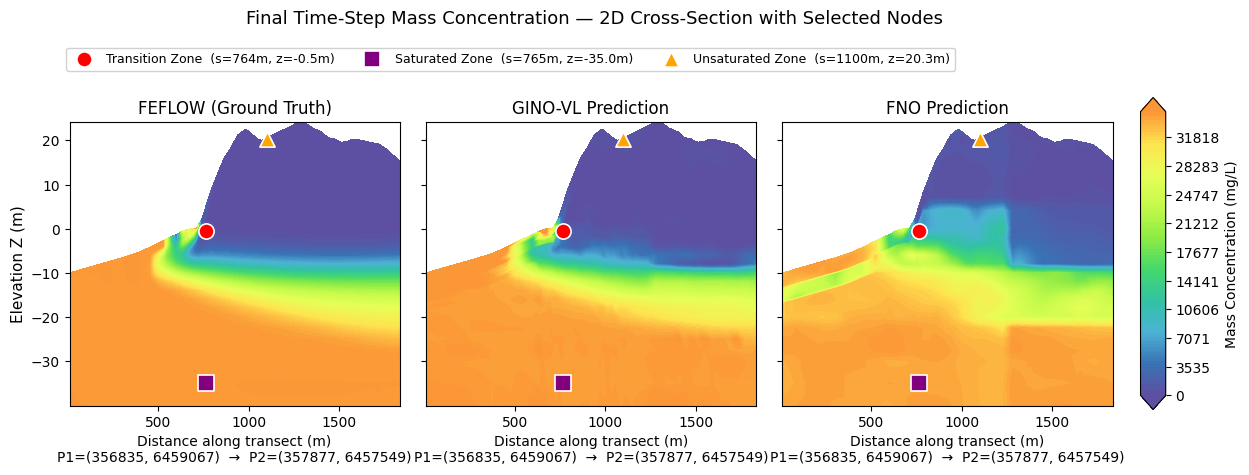

In [14]:
# ── FEFLOW colour scheme (from cross_section_analysis.ipynb) ─────────────────
feflow_colors = [
    '#5E4FA2',  # < 0       (Purple)
    '#3973B5',  # 0–1000    (Medium Blue)
    '#4CB2D4',  # 1000–5000 (Cyan)
    '#32C2A3',  # 5000–10000 (Teal)
    '#45D86A',  # 10000–15000 (Light Green)
    '#8DEB45',  # 15000–20000 (Lime Green)
    '#C4FA4B',  # 20000–25000 (Yellow-Green)
    '#E7FE57',  # 25000–30000 (Pale Yellow)
    '#FEE44F',  # 30000–34500 (Golden Yellow)
    '#FB9736',  # > 34500   (Orange)
]
cmap_cont = mcolors.LinearSegmentedColormap.from_list('feflow', feflow_colors)
norm_cont = mcolors.Normalize(vmin=0, vmax=35000)
contour_kw = dict(levels=np.linspace(0, 35000, 100), cmap=cmap_cont, norm=norm_cont, extend='both')

triangulation = mtri.Triangulation(s_coords, z_coords, triangles)

# Marker styles for the 3 selected nodes
node_colors  = {'Transition Zone': 'red',    'Saturated Zone': 'purple', 'Unsaturated Zone': 'orange'}
node_markers = {'Transition Zone': 'o',      'Saturated Zone': 's',      'Unsaturated Zone': '^'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
panels = [
    ('FEFLOW (Ground Truth)',  gt_vals),
    ('GINO-VL Prediction',     gino_vl_vals),
    ('FNO Prediction',         fno_vals),
]

for ax_i, (ax, (title, field)) in enumerate(zip(axes, panels)):
    cf = ax.tricontourf(triangulation, field, **contour_kw)
    ax.set_title(title, fontsize=12)
    ax.set_facecolor('white')
    ax.set_xlabel(
        f'Distance along transect (m)\nP1=({p1[0]:.0f}, {p1[1]:.0f})  →  P2=({p2[0]:.0f}, {p2[1]:.0f})',
        fontsize=10)

    # Overlay selected nodes — only attach labels on the first panel
    for name, idx in selected.items():
        ax.scatter(s_nodes[idx], z_nodes[idx],
                   c=node_colors[name], marker=node_markers[name],
                   s=120, zorder=10, edgecolors='white', linewidths=1.2,
                   label=f"{name}  (s={s_nodes[idx]:.0f}m, z={z_nodes[idx]:.1f}m)"
                         if ax_i == 0 else None)

axes[0].set_ylabel('Elevation Z (m)', fontsize=11)

# Single legend above all subplots (handles from first axis only)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center', ncol=len(selected),
           fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.44, 1.02))   # centred over the 3 panels (left of colourbar)

# Shared colourbar
fig.subplots_adjust(right=0.87, top=0.82, wspace=0.08)
cbar_ax = fig.add_axes([0.89, 0.10, 0.018, 0.78])
cbar    = fig.colorbar(cf, cax=cbar_ax, label='Mass Concentration (mg/L)', extend='both')

plt.suptitle(
    'Final Time-Step Mass Concentration — 2D Cross-Section with Selected Nodes',
    fontsize=13, y=1.10)
plt.show()


## Time-Series Model Comparison for Selected Nodes

For each of the three selected nodes we plot the full time series of **Mass Concentration** and **Hydraulic Head** for FEFLOW, FNO, and GINO-VL.

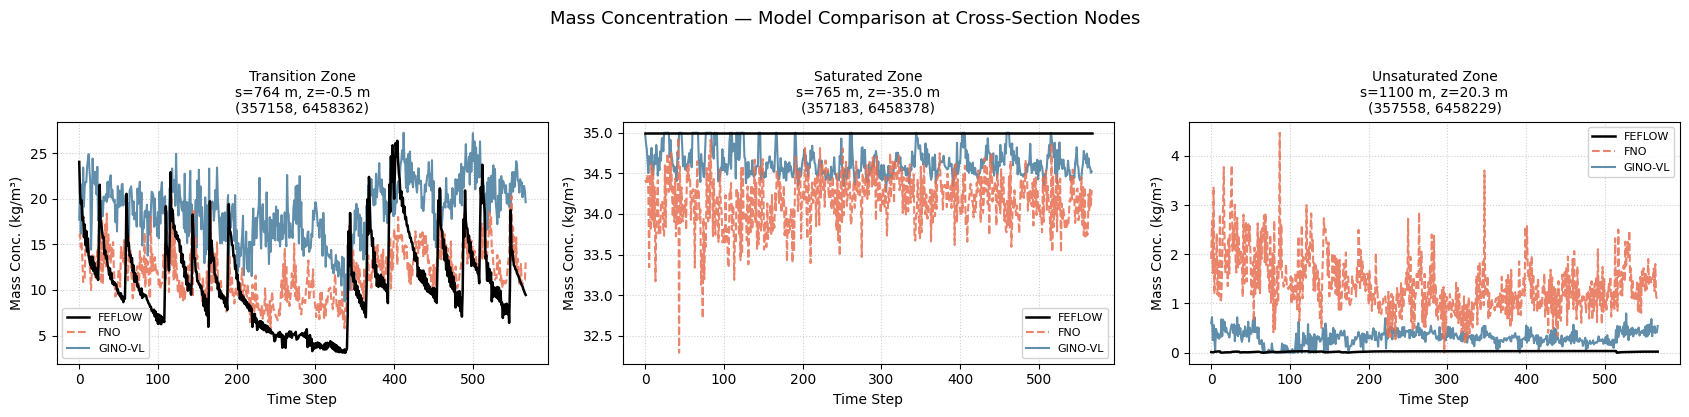

In [15]:
# ── Global unit scale (set once, applied to all panels consistently) ──────────
# mc_global_scale is already computed in the node-selection cell above.

region_order = ['Transition Zone', 'Saturated Zone', 'Unsaturated Zone']

# ── Mass Concentration ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=False)
fig.suptitle('Mass Concentration — Model Comparison at Cross-Section Nodes',
             fontsize=13, y=1.03)

for ax, name in zip(axes, region_order):
    idx = selected[name]
    obs_v  = np.clip(fno_obs[idx, :, 0]      / mc_global_scale, 0, 35)
    fno_v  = np.clip(fno_preds[idx, :, 0]    / mc_global_scale, 0, 35)
    gvl_v  = np.clip(gino_vl_preds[idx, :, 0] / mc_global_scale, 0, 35)

    ax.plot(obs_v, label='FEFLOW',   color='black',   lw=1.8,  zorder=4)
    ax.plot(fno_v, label='FNO',      color='#E76F51', lw=1.5,  linestyle='--', alpha=0.85, zorder=3)
    ax.plot(gvl_v, label='GINO-VL',  color='#457B9D', lw=1.5,  alpha=0.85, zorder=2)

    coord_str = (f"s={s_nodes[idx]:.0f} m, z={z_nodes[idx]:.1f} m\n"
                 f"({unnorm_coords[idx,0]:.0f}, {unnorm_coords[idx,1]:.0f})")
    ax.set_title(f'{name}\n{coord_str}', fontsize=10)
    ax.set_xlabel('Time Step', fontsize=10)
    ax.set_ylabel('Mass Conc. (kg/m³)', fontsize=10)
    ax.legend(loc='best', fontsize=8, framealpha=0.85)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


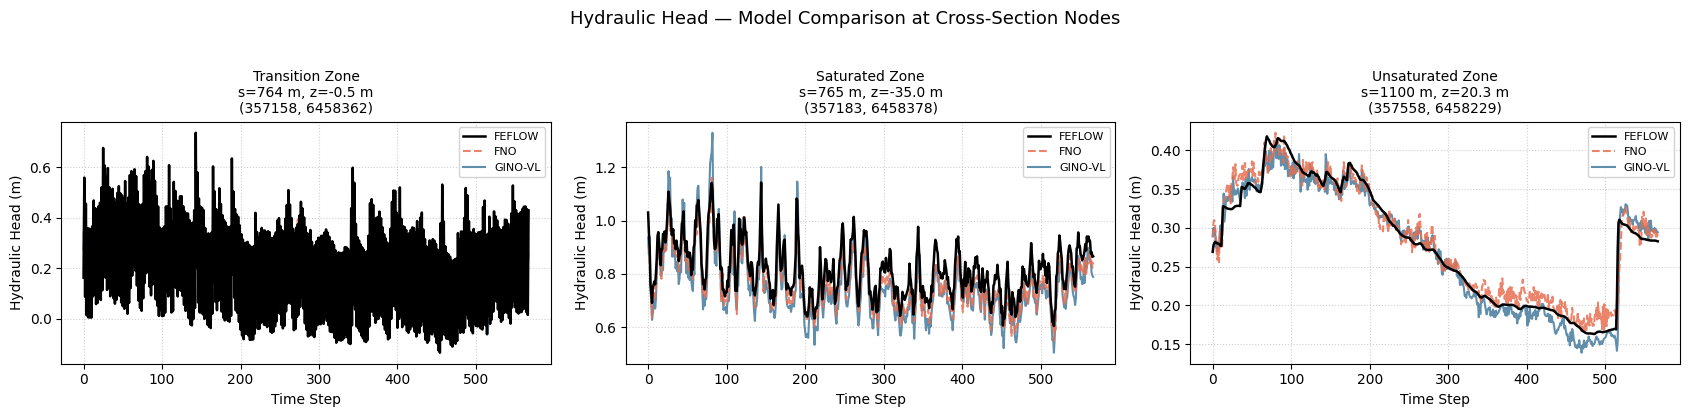

In [16]:
# ── Hydraulic Head ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=False)
fig.suptitle('Hydraulic Head — Model Comparison at Cross-Section Nodes',
             fontsize=13, y=1.03)

for ax, name in zip(axes, region_order):
    idx = selected[name]

    ax.plot(fno_obs[idx, :, 1],      label='FEFLOW', color='black',   lw=1.8,  zorder=4)
    ax.plot(fno_preds[idx, :, 1],    label='FNO',    color='#E76F51', lw=1.5,  linestyle='--',  alpha=0.85, zorder=3)
    ax.plot(gino_vl_preds[idx,:, 1], label='GINO-VL',color='#457B9D',lw=1.5,  alpha=0.85, zorder=2)

    coord_str = (f"s={s_nodes[idx]:.0f} m, z={z_nodes[idx]:.1f} m\n"
                 f"({unnorm_coords[idx,0]:.0f}, {unnorm_coords[idx,1]:.0f})")
    ax.set_title(f'{name}\n{coord_str}', fontsize=10)
    ax.set_xlabel('Time Step', fontsize=10)
    ax.set_ylabel('Hydraulic Head (m)', fontsize=10)
    ax.legend(loc='best', fontsize=8, framealpha=0.85)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Summary: Selected Node Positions on the Cross-Section

A quick scatter of all corridor nodes (coloured by ground-truth mass concentration at the final timestep), with the three selected nodes highlighted.

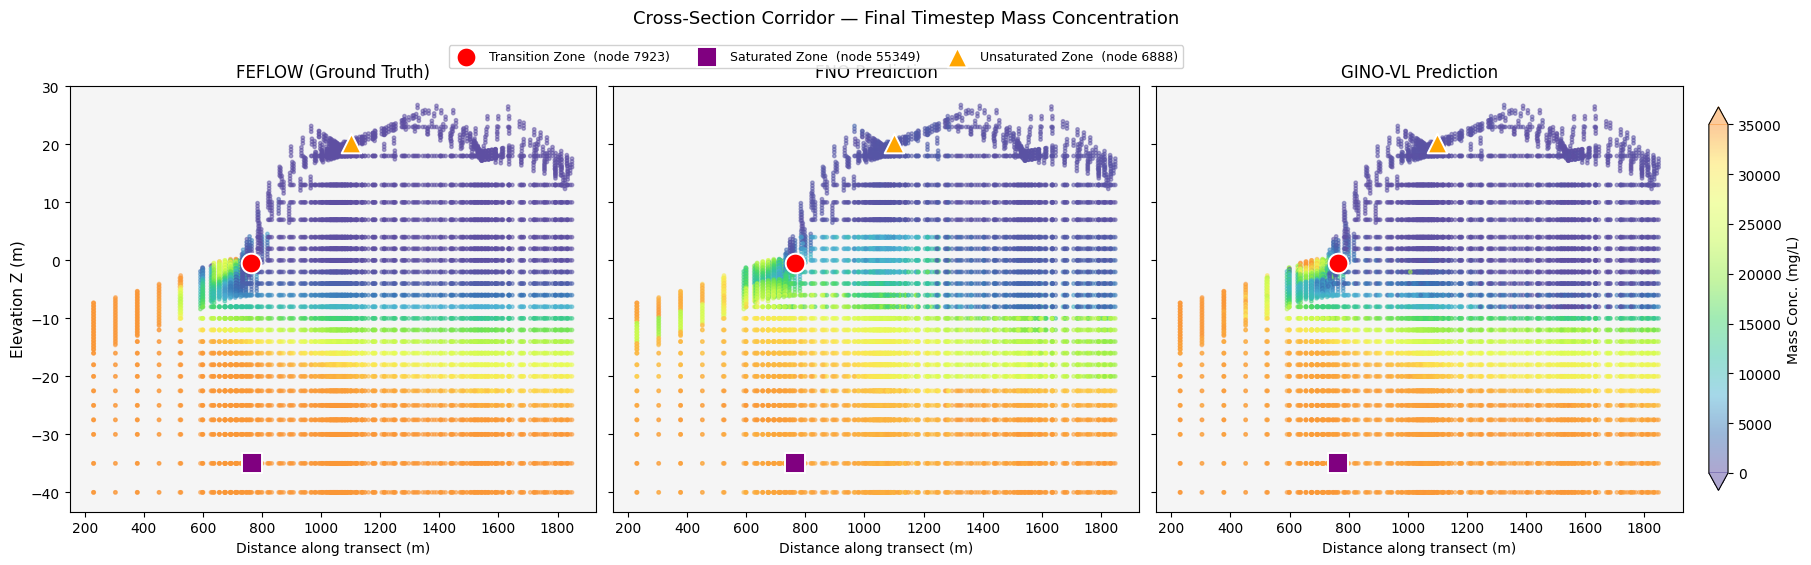

In [17]:
# ── All-corridor scatter grid — ground truth, FNO, GINO-VL ───────────────────
# Three side-by-side panels using the same FEFLOW colour scale, each showing
# all corridor nodes coloured by the final-timestep mass concentration.

scatter_panels = [
    ('FEFLOW (Ground Truth)',  fno_obs[:,  -1, 0]),
    ('FNO Prediction',         fno_preds[:, -1, 0]),
    ('GINO-VL Prediction',     gino_vl_preds[:, -1, 0]),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True,
                         constrained_layout=True)

for ax, (title, field) in zip(axes, scatter_panels):
    sc = ax.scatter(
        s_nodes[in_corridor], z_nodes[in_corridor],
        c=field[in_corridor],
        cmap=cmap_cont, norm=norm_cont,
        s=6, alpha=0.5, rasterized=True,
    )
    # Overlay selected nodes
    for name, idx in selected.items():
        ax.scatter(s_nodes[idx], z_nodes[idx],
                   c=node_colors[name], marker=node_markers[name],
                   s=200, zorder=10, edgecolors='white', linewidths=1.4,
                   label=f"{name}  (node {idx})")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Distance along transect (m)', fontsize=10)
    ax.set_facecolor('#f5f5f5')

axes[0].set_ylabel('Elevation Z (m)', fontsize=11)

# Shared legend (handles from first axis)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center', ncol=len(selected),
           fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.45, 1.04))

# Shared colourbar on the right
cbar = fig.colorbar(sc, ax=axes[-1], label='Mass Conc. (mg/L)',
                    extend='both', shrink=0.9)

fig.suptitle(
    'Cross-Section Corridor — Final Timestep Mass Concentration',
    fontsize=13, y=1.10)
plt.show()
